# CovNet

In [1]:
import covnet
import torch
import pickle
from torch.utils.data import DataLoader

# Dataset

The dataset was created from AGPIL instances. For every polygon $P$ we sampled subset of optimal guards $G^{(i)}=\{g_1,g_2,\ldots,g_{n(i)}\}$, $i=1,2,\ldots,k$ and evaluated the coverage of polygon $c(P,G^{(i)})=\textrm{Vis}(P,G^{(i)})/\textrm{Area}(P)$. Therefore, our dataset consists of $k$ triples $(P,G_i,c(P,G_i))$ for every instance.

For the training purposes, we used instances of up to 200 vertices and generated $k=40$ samples of guards for every instance. 

In [2]:
# data
with open('data/medium_data_40.pickle','rb') as f:
        data = pickle.load(f)

# split data to train, valid and test
_, _, test_set = data[0], data[1], data[2]
test_generator  = DataLoader(test_set,  shuffle=False,batch_size=1,collate_fn=covnet.collate_fn_packed)

In [3]:
# model
from covnet import CovNet,Encoder, Aggregator

model = torch.load(f'models/covnet.pt')

print(model)

CovNet(
  (poly_encoder): Encoder(
    (lstm): LSTM(3, 50, num_layers=3, batch_first=True, dropout=0.5)
  )
  (sol_encoder): Encoder(
    (lstm): LSTM(3, 50, num_layers=3, batch_first=True, dropout=0.5)
  )
  (aggregator): Aggregator(
    (aggregate): Sequential(
      (0): Linear(in_features=100, out_features=1, bias=True)
      (1): Sigmoid()
    )
  )
)


Results written to results/results.png
MAE error on test set of size 7524:  0.06939615309238434
R2 score on test set of size 7524:  0.8951588869094849


,x,y,diff
0,0.152774,0.026820,0.125954
1,0.321734,0.313646,0.008087
2,0.739374,0.712429,0.026945
3,0.825346,0.832483,0.007137
4,0.840268,0.689211,0.151057
...,...,...,...
7519,0.643472,0.577347,0.066125
7520,0.896776,0.986281,0.089505
7521,0.506695,0.169775,0.336921
7522,0.786045,0.839279,0.053233


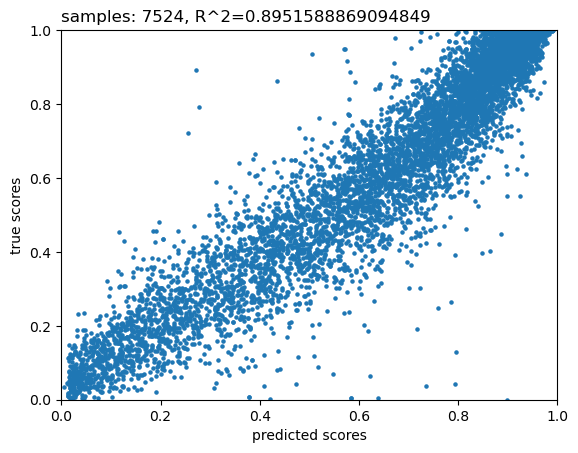

In [4]:
df,img = covnet.evaluate_prediction(model,test_generator)

df

In [ ]:
# read solution from clusters
 instances = generate_instances(name,sol_sample=train_args.sol_sample)

In [2]:
# convert to pandas
import pandas as pd


df = pd.read_json('results/results_1.json')
df


,counts,mean coverage,std coverage,mean ratio,std ratio
.*?-[1-5]\d-,149,0.952521,0.082152,6.255034,2.43342
.*?-[6-9]\d-,219,0.934971,0.057811,11.753425,2.52719
.*?-1\d\d-,853,0.874538,0.074838,19.894490,4.19100
